# MLP BASED PPREDICTION

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

## DATA PREPERATION

In [99]:
df = pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False)
df['power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df['day'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

daily_avg_df = df.groupby('day', as_index=False)['power'].mean()

daily_avg_df['doy'] = daily_avg_df['day'].dt.dayofyear
daily_avg_df['dow'] = daily_avg_df['day'].dt.dayofweek
daily_avg_df['year'] = daily_avg_df['day'].dt.year

daily_avg_df['doy_sin'] = np.sin(2 * np.pi * daily_avg_df['doy'] / 365.0)
daily_avg_df['doy_cos'] = np.cos(2 * np.pi * daily_avg_df['doy'] / 365.0)
daily_avg_df['dow_sin'] = np.sin(2 * np.pi * daily_avg_df['dow'] / 7.0)
daily_avg_df['dow_cos'] = np.cos(2 * np.pi * daily_avg_df['dow'] / 7.0)

daily_avg_df['past_7d_avg'] = daily_avg_df['power'].shift(1).rolling(window=7).mean()
daily_avg_df = daily_avg_df.dropna().reset_index(drop=True)

mean_7d = daily_avg_df['past_7d_avg'].mean()
std_7d = daily_avg_df['past_7d_avg'].std()
daily_avg_df['norm_past_7d_avg'] = (daily_avg_df['past_7d_avg'] - mean_7d) / std_7d

final_df = daily_avg_df[[
    'day', 'year',                
    'doy_sin', 'doy_cos',         
    'dow_sin', 'dow_cos',         
    'past_7d_avg', 'norm_past_7d_avg',  # <--- Comma added here          
    'power'                       
]]

In [100]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,power,day
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0,4.216,2006-12-16
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0,5.360,2006-12-16
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0,5.374,2006-12-16
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0,5.388,2006-12-16
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0,3.666,2006-12-16


## VISUALIZATION

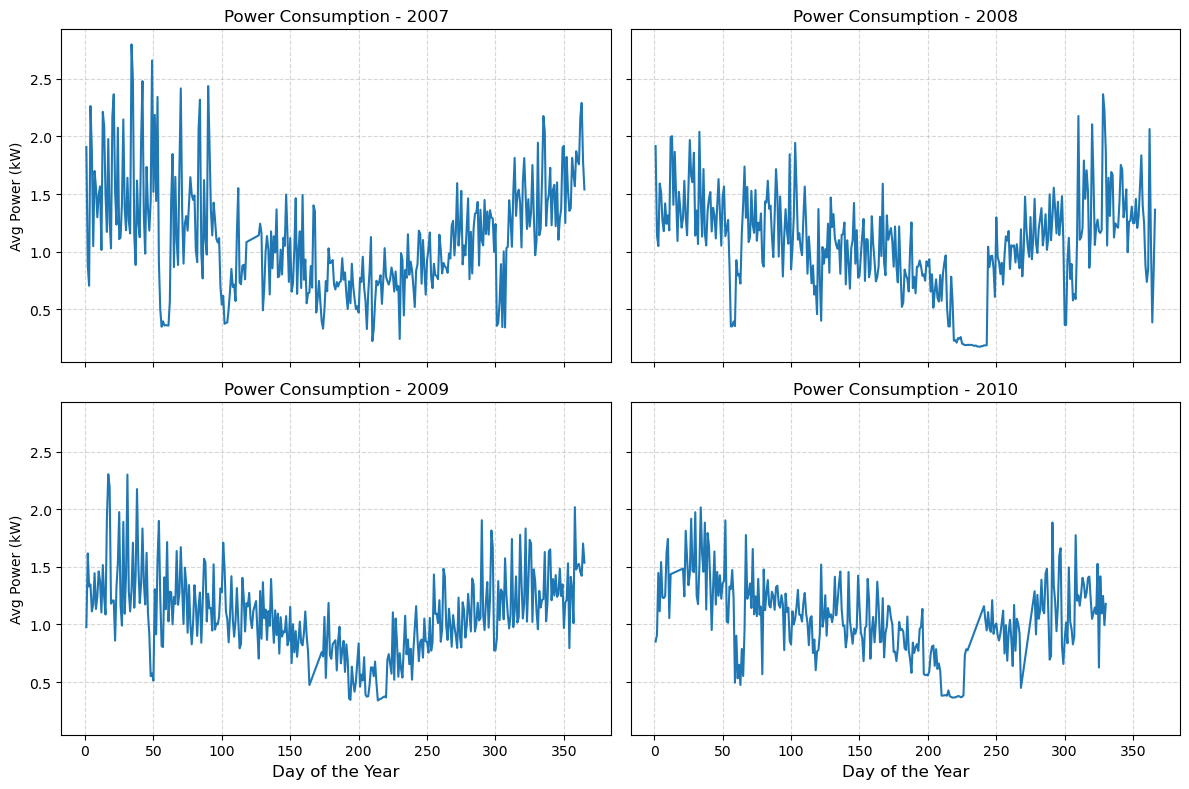

In [101]:
unique_years = daily_avg_df['year'].dropna().unique().astype(int).tolist()
years_to_plot = [y for y in unique_years if y >= 2007]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8), sharex=True, sharey=True)

axes_flat = axes.flatten()

for i, year in enumerate(years_to_plot):
    year_data = daily_avg_df[daily_avg_df['year'] == year]
    
    axes_flat[i].plot(year_data['doy'], year_data['power'], color='tab:blue', linewidth=1.5)  
    
    axes_flat[i].set_title(f'Power Consumption - {year}', fontsize=12)
    axes_flat[i].grid(True, linestyle='--', alpha=0.5)

axes_flat[0].set_ylabel('Avg Power (kW)')
axes_flat[2].set_ylabel('Avg Power (kW)')

axes_flat[2].set_xlabel('Day of the Year', fontsize=12)
axes_flat[3].set_xlabel('Day of the Year', fontsize=12)

plt.tight_layout()
plt.show()

In [102]:
final_df.head()

,day,year,doy_sin,doy_cos,dow_sin,dow_cos,past_7d_avg,norm_past_7d_avg,power
0,2006-12-23,2006,-0.137279,0.990532,-0.974928,-0.222521,1.780117,2.132978,3.314851
1,2006-12-24,2006,-0.120208,0.992749,-0.781831,0.623490,1.817457,2.248894,1.770842
2,2006-12-25,2006,-0.103102,0.994671,0.000000,1.000000,1.734079,1.990057,1.904944
3,2006-12-26,2006,-0.085965,0.996298,0.781831,0.623490,1.787580,2.156147,2.732021
4,2006-12-27,2006,-0.068802,0.997630,0.974928,-0.222521,2.012572,2.854608,1.061639


## Model Architecture: Daily Power Prediction

This network utilizes cyclical time encodings (Sine/Cosine vectors) alongside historical power averages to forecast daily energy consumption.

### Architecture Flow

```text
       [ Input Features ]
 ┌─────────────┼─────────────┐
 │             │             │
DOY           DOW       Past 7-Day
(2-Dim)       (2-Dim)   Average (1-Dim)
 │             │             │
 └─────────────┼─────────────┘
               ▼
        [ Input Layer ] (5 Dimensions)
               │
               ▼
      ( Tanh Activation )
               │
               ▼
       [ Hidden Layer ]
               │
               ▼
      ( Tanh Activation )
               │
               ▼
        [ Output Layer ]
               │
               ▼
         [ Prediction ]

In [103]:
class AdvancedPowerPredictor(nn.Module):
    def __init__(self, input_dim=5):
        super(AdvancedPowerPredictor, self).__init__()
        
        self.layer1 = nn.Linear(input_dim, 32)
        self.bn1 = nn.BatchNorm1d(32)
        self.activation1 = nn.LeakyReLU(0.1)
        self.dropout1 = nn.Dropout(0.2)
        
        self.layer2 = nn.Linear(32, 16)
        self.bn2 = nn.BatchNorm1d(16)
        self.activation2 = nn.LeakyReLU(0.1)
        self.dropout2 = nn.Dropout(0.2)
        
        self.output_layer = nn.Linear(16, 1)
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.dropout1(x)
        
        x = self.layer2(x)
        x = self.bn2(x)
        x = self.activation2(x)
        x = self.dropout2(x)
        
        x = self.output_layer(x)
        return x

Training on 2007-2009 | Testing on 2010...
Epoch [1/150] | Train Loss: 1.5448 | Test Loss: 1.0366
Epoch [15/150] | Train Loss: 0.1590 | Test Loss: 0.0698
Epoch [30/150] | Train Loss: 0.1305 | Test Loss: 0.0638
Epoch [45/150] | Train Loss: 0.1077 | Test Loss: 0.0630
Epoch [60/150] | Train Loss: 0.1036 | Test Loss: 0.0616
Epoch [75/150] | Train Loss: 0.1009 | Test Loss: 0.0626
Epoch [90/150] | Train Loss: 0.0964 | Test Loss: 0.0620
Epoch [105/150] | Train Loss: 0.0914 | Test Loss: 0.0644
Epoch [120/150] | Train Loss: 0.0938 | Test Loss: 0.0630
Epoch [135/150] | Train Loss: 0.0915 | Test Loss: 0.0617
Epoch [150/150] | Train Loss: 0.0911 | Test Loss: 0.0615


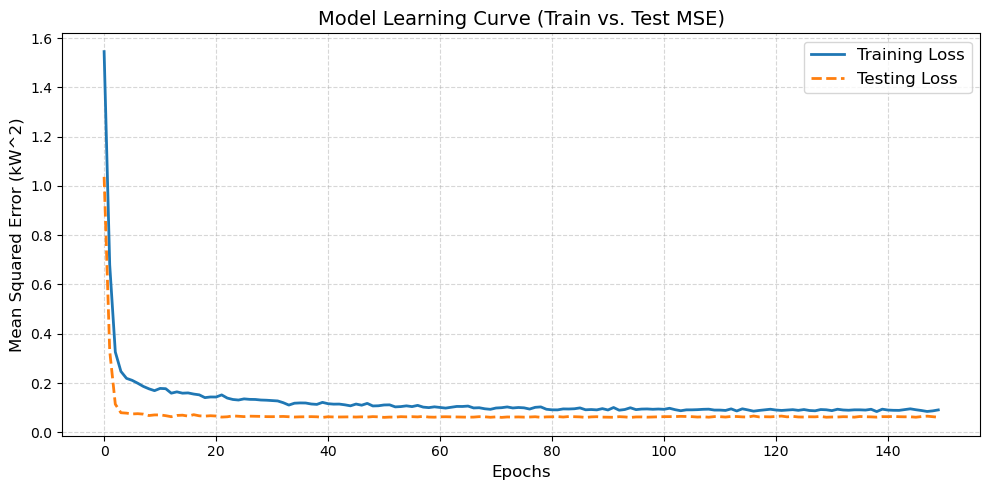

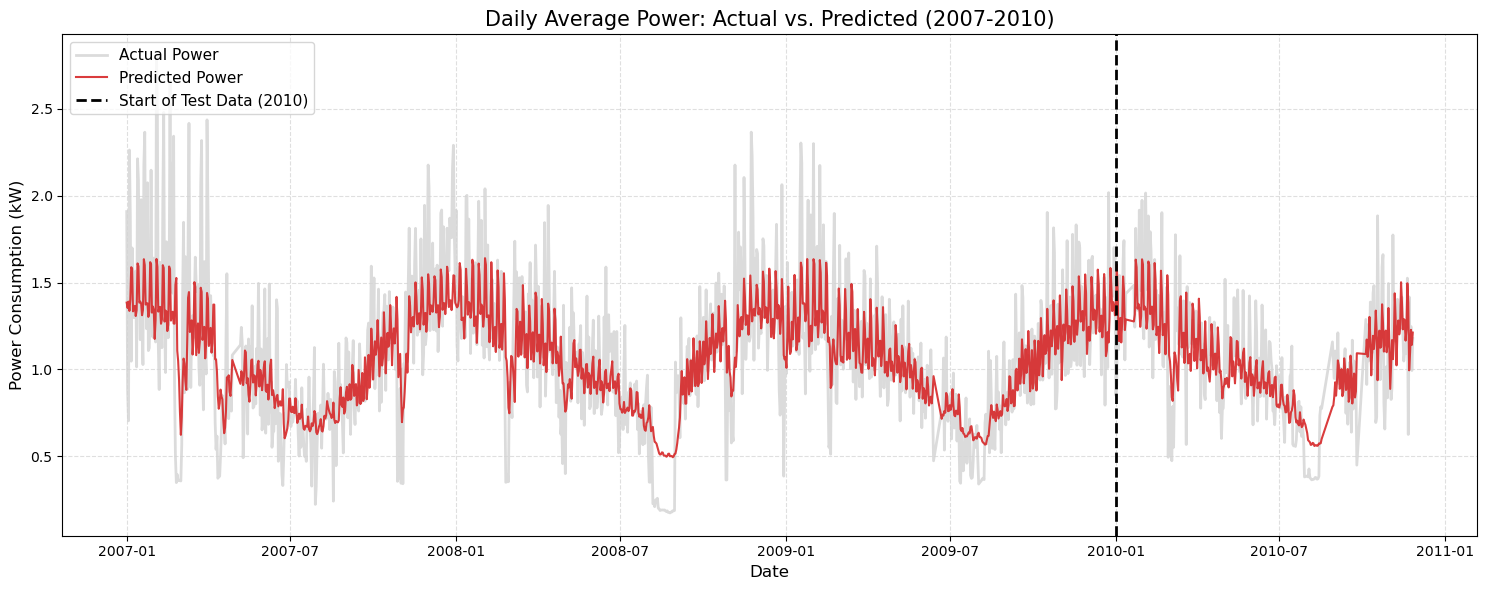

In [104]:
df_2007 = final_df[final_df['year'] >= 2007].copy()

train_df = df_2007[df_2007['year'] < 2010].copy()
test_df = df_2007[df_2007['year'] >= 2010].copy()

feature_cols = ['doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'norm_past_7d_avg']

X_train = torch.tensor(train_df[feature_cols].values.astype(np.float32))
y_train = torch.tensor(train_df['power'].values.astype(np.float32).reshape(-1, 1))

X_test = torch.tensor(test_df[feature_cols].values.astype(np.float32))
y_test = torch.tensor(test_df['power'].values.astype(np.float32).reshape(-1, 1))

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)

model = AdvancedPowerPredictor(input_dim=5)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.003, weight_decay=0.01)

epochs = 150
train_losses = []
test_losses = []

print("Training on 2007-2009 | Testing on 2010...")
for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)
    
    avg_train_loss = epoch_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    
    model.eval()
    epoch_test_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            epoch_test_loss += loss.item() * batch_X.size(0)
            
    avg_test_loss = epoch_test_loss / len(test_loader.dataset)
    test_losses.append(avg_test_loss)
    
    if (epoch + 1) % 15 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")

model.eval()
X_all = torch.tensor(df_2007[feature_cols].values.astype(np.float32))
with torch.no_grad():
    all_predictions = model(X_all).numpy()

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', color='tab:blue', linewidth=2)
plt.plot(test_losses, label='Testing Loss', color='tab:orange', linewidth=2, linestyle='--')

plt.title('Model Learning Curve (Train vs. Test MSE)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (kW^2)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))

plt.plot(df_2007['day'], df_2007['power'], label='Actual Power', color='lightgray', linewidth=2, alpha=0.8)

plt.plot(df_2007['day'], all_predictions, label='Predicted Power', color='tab:red', linewidth=1.5, alpha=0.9)

test_start_date = pd.to_datetime('2010-01-01')
plt.axvline(x=test_start_date, color='black', linestyle='--', linewidth=2, label='Start of Test Data (2010)')

plt.title('Daily Average Power: Actual vs. Predicted (2007-2010)', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Power Consumption (kW)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

/tmp/ipykernel_13966/34761902.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(param_values, labels=param_names, vert=False, patch_artist=True,


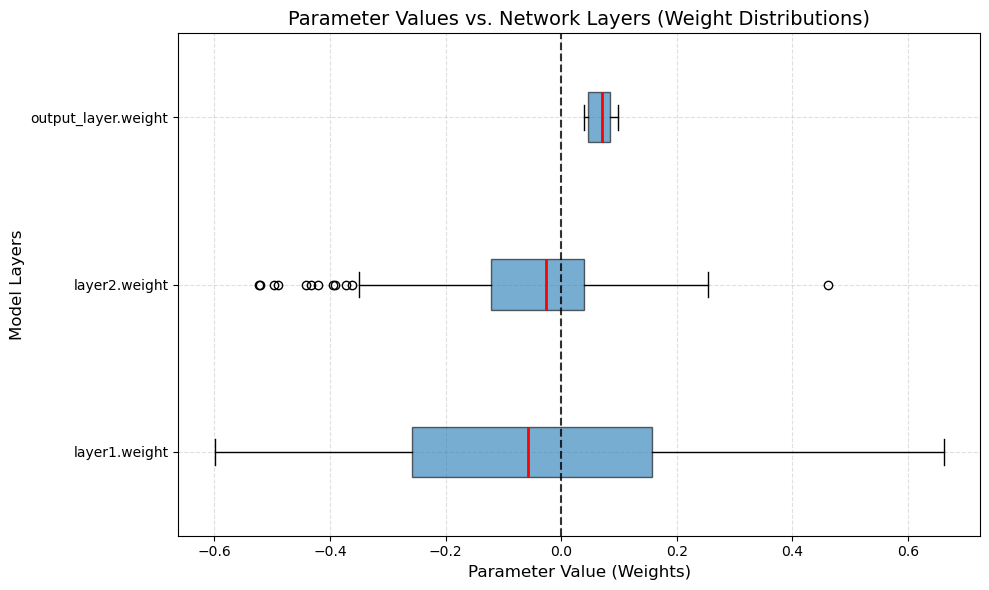

In [105]:
param_names = []
param_values = []

for name, param in model.named_parameters():
    if 'weight' in name and 'bn' not in name:
        param_names.append(name)
        param_values.append(param.detach().numpy().flatten())

plt.figure(figsize=(10, 6))

plt.boxplot(param_values, labels=param_names, vert=False, patch_artist=True,
            boxprops=dict(facecolor='tab:blue', color='black', alpha=0.6),
            medianprops=dict(color='red', linewidth=2))

plt.title('Parameter Values vs. Network Layers (Weight Distributions)', fontsize=14)
plt.xlabel('Parameter Value (Weights)', fontsize=12)
plt.ylabel('Model Layers', fontsize=12)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.8)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

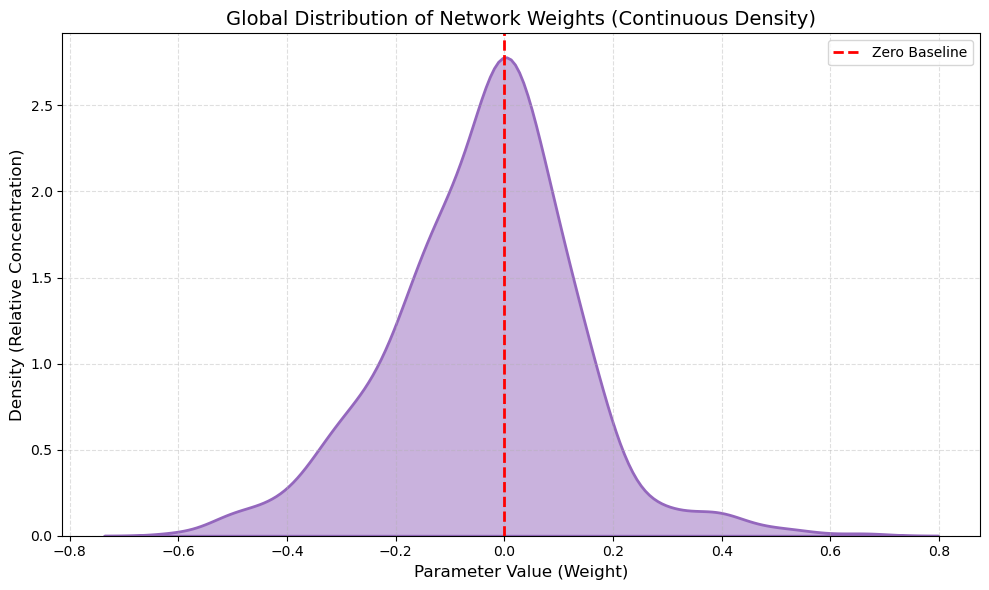

In [106]:
all_weights = []

for name, param in model.named_parameters():
    if 'weight' in name and 'bn' not in name:
        all_weights.extend(param.detach().numpy().flatten())

all_weights = np.array(all_weights)

plt.figure(figsize=(10, 6))
sns.kdeplot(all_weights, color='tab:purple', fill=True, alpha=0.5, linewidth=2)

plt.title('Global Distribution of Network Weights (Continuous Density)', fontsize=14)
plt.xlabel('Parameter Value (Weight)', fontsize=12)
plt.ylabel('Density (Relative Concentration)', fontsize=12)

plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Baseline')

plt.legend(loc='upper right')
plt.grid(axis='both', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

In [107]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
        
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
        
    total_size_bytes = param_size + buffer_size
    total_size_kb = total_size_bytes / 1024
    total_size_mb = total_size_bytes / (1024 ** 2)
    
    print("=" * 40)
    print("MODEL SIZE DIAGNOSTICS")
    print("=" * 40)
    print(f"Total Parameters:      {total_params:,}")
    print(f"Trainable Parameters:  {trainable_params:,}")
    print("-" * 40)
    print(f"Total Memory Size:     {total_size_bytes:,} Bytes")
    print(f"                       {total_size_kb:.3f} KB")
    print(f"                       {total_size_mb:.6f} MB")
    print("=" * 40)

print_model_size(model)

MODEL SIZE DIAGNOSTICS
Total Parameters:      833
Trainable Parameters:  833
----------------------------------------
Total Memory Size:     3,732 Bytes
                       3.645 KB
                       0.003559 MB


Deploying Model to Edge Device...
Total simulated days: 1391
Day 0060 Update | Train Loss: 3.2453 | Next 60D Test Loss: 1.5629
Day 0120 Update | Train Loss: 1.9059 | Next 60D Test Loss: 1.7221
Day 0180 Update | Train Loss: 1.1472 | Next 60D Test Loss: 0.9299
Day 0240 Update | Train Loss: 0.6236 | Next 60D Test Loss: 0.6117
Day 0300 Update | Train Loss: 0.8830 | Next 60D Test Loss: 0.8067
Day 0360 Update | Train Loss: 0.8729 | Next 60D Test Loss: 1.0429
Day 0420 Update | Train Loss: 0.8673 | Next 60D Test Loss: 0.8318
Day 0480 Update | Train Loss: 0.5723 | Next 60D Test Loss: 0.6049
Day 0540 Update | Train Loss: 0.2994 | Next 60D Test Loss: 0.1901
Day 0600 Update | Train Loss: 0.2101 | Next 60D Test Loss: 0.1158
Day 0660 Update | Train Loss: 0.2040 | Next 60D Test Loss: 0.2497
Day 0720 Update | Train Loss: 0.3319 | Next 60D Test Loss: 0.3402
Day 0780 Update | Train Loss: 0.2799 | Next 60D Test Loss: 0.2457
Day 0840 Update | Train Loss: 0.2913 | Next 60D Test Loss: 0.1222
Day 0900 Update

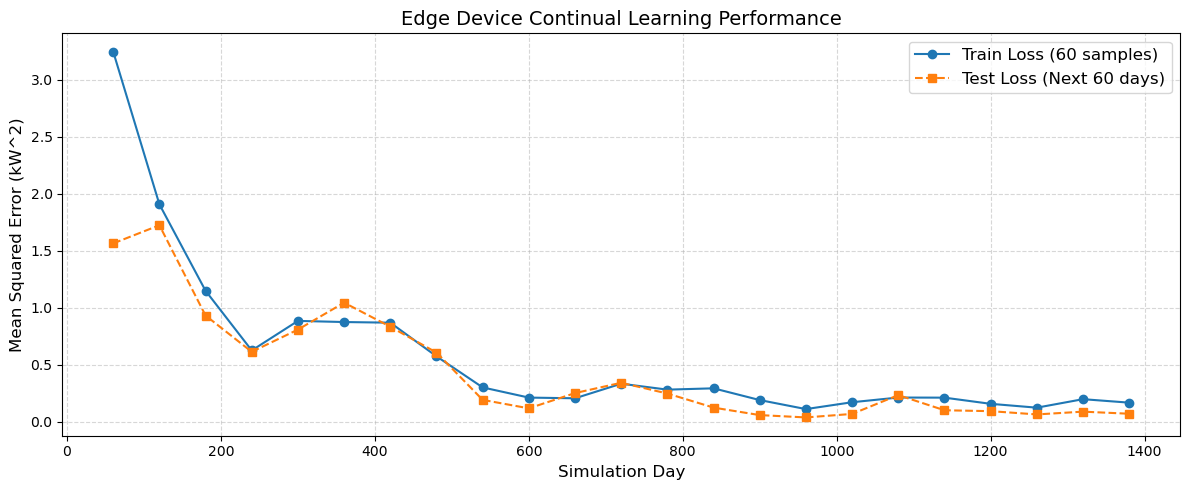

In [108]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

X_all = final_df[feature_cols].values.astype(np.float32)
y_all = final_df['power'].values.astype(np.float32).reshape(-1, 1)

total_days = len(final_df)
update_interval = 60  
edge_epochs = 15      

edge_model = AdvancedPowerPredictor(input_dim=5)
criterion = nn.MSELoss()
optimizer = optim.AdamW(edge_model.parameters(), lr=0.001, weight_decay=0.01)

cycle_days = []
edge_train_losses = []
edge_test_losses = []

print("Deploying Model to Edge Device...")
print(f"Total simulated days: {total_days}")

for current_day in range(update_interval, total_days, update_interval):
    
    recent_indices = np.arange(current_day - 30, current_day)
    
    available_past = np.arange(0, current_day - 30)
    
    if len(available_past) > 30:
        past_indices = np.random.choice(available_past, size=30, replace=False)
    else:
        past_indices = available_past 
        
    train_indices = np.concatenate((past_indices, recent_indices))
    np.random.shuffle(train_indices)
    
    test_end = min(current_day + update_interval, total_days)
    test_indices = np.arange(current_day, test_end)
    
    if len(test_indices) == 0:
        break
        
    X_train_edge = torch.tensor(X_all[train_indices])
    y_train_edge = torch.tensor(y_all[train_indices])
    
    X_test_edge = torch.tensor(X_all[test_indices])
    y_test_edge = torch.tensor(y_all[test_indices])
    
    edge_model.train()
    cycle_train_loss = 0.0
    
    for epoch in range(edge_epochs):
        optimizer.zero_grad()
        preds = edge_model(X_train_edge)
        loss = criterion(preds, y_train_edge)
        loss.backward()
        optimizer.step()
        cycle_train_loss = loss.item()
        
    edge_train_losses.append(cycle_train_loss)
    
    edge_model.eval()
    with torch.no_grad():
        test_preds = edge_model(X_test_edge)
        test_loss = criterion(test_preds, y_test_edge).item()
        
    edge_test_losses.append(test_loss)
    cycle_days.append(current_day)
    
    print(f"Day {current_day:04d} Update | Train Loss: {cycle_train_loss:.4f} | Next 60D Test Loss: {test_loss:.4f}")

print("Simulation Complete!")

plt.figure(figsize=(12, 5))
plt.plot(cycle_days, edge_train_losses, label='Train Loss (60 samples)', color='tab:blue', marker='o')
plt.plot(cycle_days, edge_test_losses, label='Test Loss (Next 60 days)', color='tab:orange', marker='s', linestyle='--')

plt.title('Edge Device Continual Learning Performance', fontsize=14)
plt.xlabel('Simulation Day', fontsize=12)
plt.ylabel('Mean Squared Error (kW^2)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

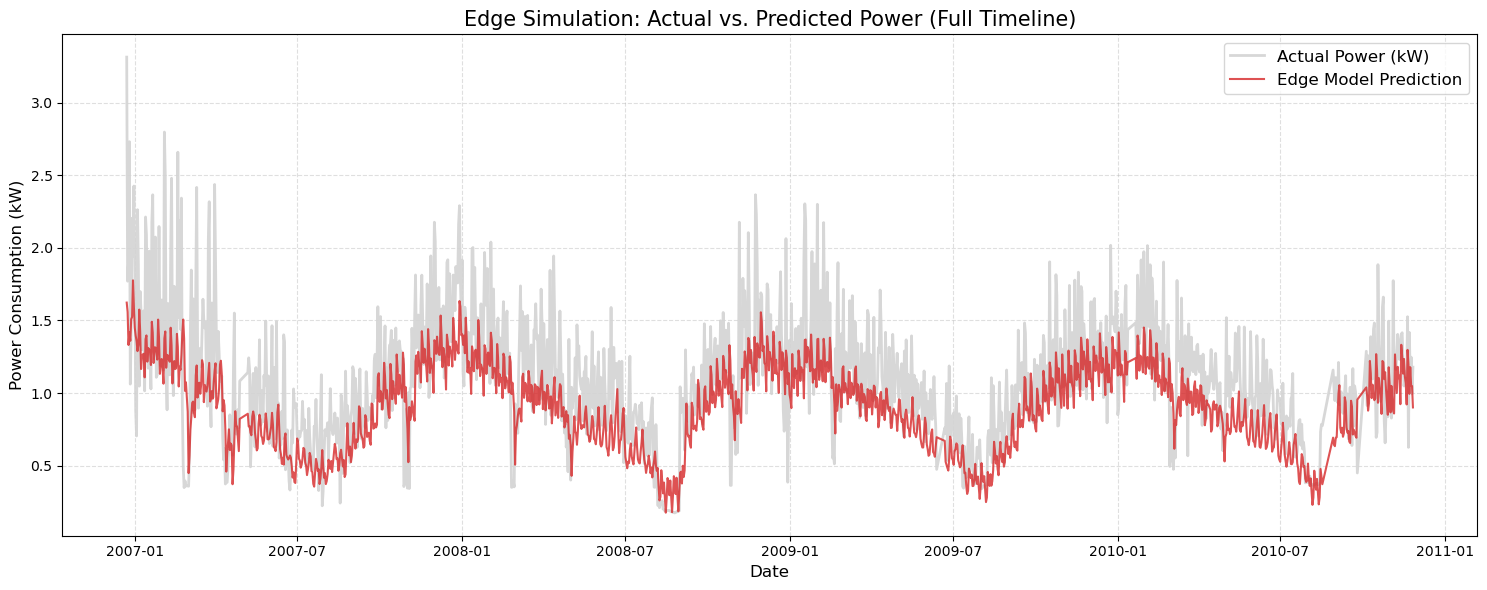

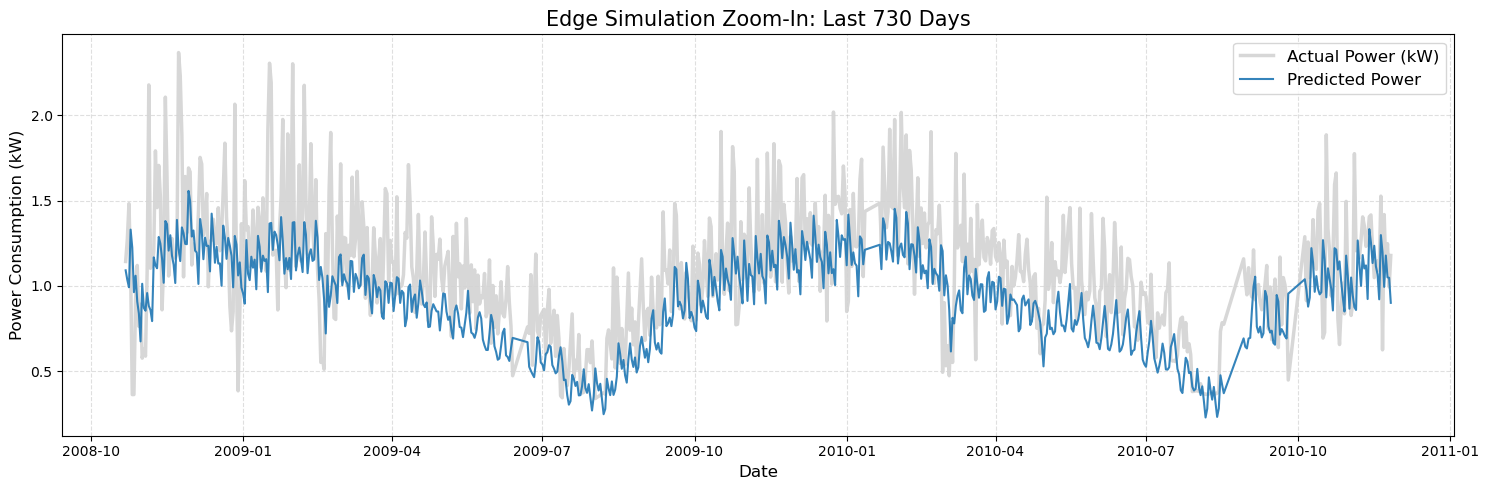

In [109]:
# 1. Run the entire dataset through the trained edge model
edge_model.eval()
with torch.no_grad():
    # X_all and y_all were defined in the previous edge simulation step
    all_edge_preds = edge_model(torch.tensor(X_all)).numpy()

# 2. Set up the main plot (Entire Timeline)
plt.figure(figsize=(15, 6))

# Plot Actual Data (Gray, slightly thick and transparent)
plt.plot(final_df['day'], y_all, label='Actual Power (kW)', color='lightgray', linewidth=2, alpha=0.9)

# Plot Predicted Data (Red, slightly thinner to sit inside the gray)
plt.plot(final_df['day'], all_edge_preds, label='Edge Model Prediction', color='tab:red', linewidth=1.5, alpha=0.8)

# Format the chart
plt.title('Edge Simulation: Actual vs. Predicted Power (Full Timeline)', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Power Consumption (kW)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. BONUS: Zoomed-in view (Last 365 Days)
# ---------------------------------------------------------
# Slicing the last 365 days makes it much easier to see the daily accuracy
zoom_days = 365 * 2

plt.figure(figsize=(15, 5))
plt.plot(final_df['day'].iloc[-zoom_days:], y_all[-zoom_days:], 
         label='Actual Power (kW)', color='lightgray', linewidth=2.5, alpha=0.9)

plt.plot(final_df['day'].iloc[-zoom_days:], all_edge_preds[-zoom_days:], 
         label='Predicted Power', color='tab:blue', linewidth=1.5, alpha=0.9)

plt.title(f'Edge Simulation Zoom-In: Last {zoom_days} Days', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Power Consumption (kW)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()